In [1]:
## ViT-X: A Modular Vision Transformer with Learnable Patch Embeddings, Relative Positional Encoding, LayerScale, Stochastic Depth, and Attention Visualization


In [2]:
#Imports
import os
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image #img processor
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms
from tqdm.notebook import tqdm #for progress bars

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device) #GPU check(T4x2)

cuda


In [4]:
def set_seed(seed=42): #reproducer function 
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)
#RPB, Layerscale, schocastic depth all change accoriding to the random sequence of initialisations

In [5]:
#Set hyperparams
IMAGE_SIZE = 224 #same as paper (dataset = 150, resizing needed)
PATCH_SIZE = 16 #same as paper
BATCH_SIZE = 32 #32 images at once
NUM_CLASSES = 6 #according to dataset 
EMBED_DIM = 384 #768 made half, each token is half as wide as the OG 
NUM_HEADS = 6 #384/6 = 64 features per attention head 
MLP_RATIO = 4 #same as paper
DEPTH = 8 #no of transformer blocks (paper = 12), intel dataset smaller
DROPOUT = 0.1 #10% random neurons turned off 
EPOCHS = 20 #exp 
LEARNING_RATE = 3e-4 #same as paper
WEIGHT_DECAY = 0.05 #common coeff set with adamW

In [6]:
#dataset
DATA_ROOT = "/kaggle/input/datasets/puneet6060/intel-image-classification"
TRAIN_DIR = os.path.join(DATA_ROOT, "seg_train", "seg_train")
TEST_DIR = os.path.join(DATA_ROOT, "seg_test", "seg_test")

In [7]:
#augmentationsss
train_transform = transforms.Compose([
    transforms.Resize((224,224)), #from 150 to 224
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])
#testset augs
test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [8]:
#apply augs and store
train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)
test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=test_transform
)

In [9]:
#check classes
class_names = train_dataset.classes
print(class_names)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [10]:
#loader
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [11]:
#sanity check
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


Test passed with correct dimensions

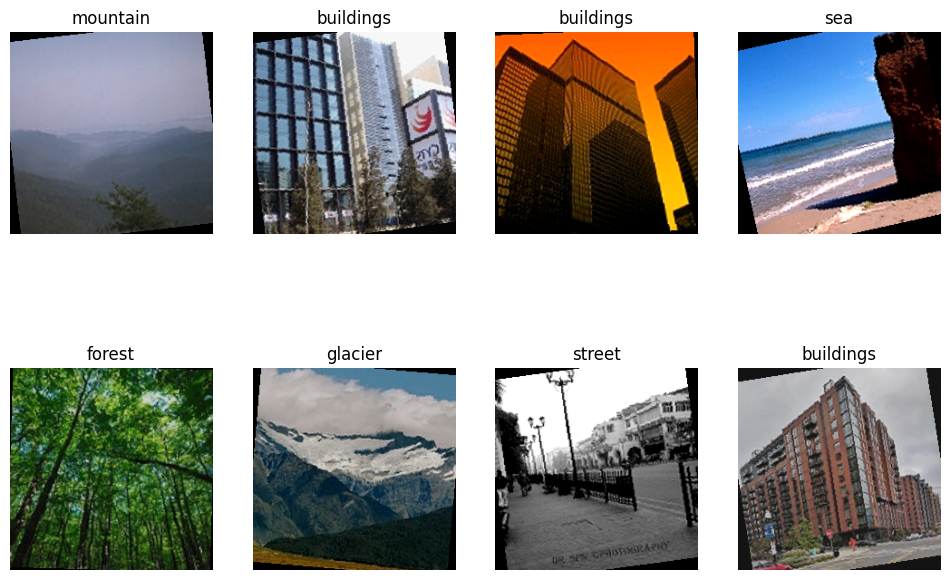

In [12]:
#Check images
def show_batch(images, labels):
    images = images.clone()
    #unnormalise
    mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    std = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
    images = images * std + mean
    images = images.clamp(0,1)
    plt.figure(figsize=(12,8))
    for i in range(8):
        plt.subplot(2,4,i+1)
        plt.imshow(images[i].permute(1,2,0))
        plt.title(class_names[labels[i]])
        plt.axis("off")
    plt.show()
show_batch(images, labels)

Check passed. Data push pipeline created.

Transformer building starts here. 

In [13]:
#Patch embeddings
#using conv2D instead of split and flatten method for speeeeeed + im lazy
class PatchEmbedding(nn.Module):
    def __init__(
        self,
        image_size=224,
        patch_size=16,
        in_channels=3,
        embed_dim=384
    ):
        super().__init__()
        self.image_size = image_size
        self.patch_size = patch_size
        # Number of patches
        self.num_patches = (image_size // patch_size) ** 2
        # Patchify + Linear Projection
        self.projection = nn.Conv2d( #stride=16, kernel=16
            in_channels=in_channels,
            out_channels=embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )
    def forward(self, x):
        #(batch,3,224,224)
        x = self.projection(x)
        #(batch,384,14,14)
        x = x.flatten(2)
        # (batch,384,196)
        x = x.transpose(1,2)
        # (batch,196,384)
        return x

In [14]:
#Test: If converted to token series
patch_embed = PatchEmbedding(
    image_size=IMAGE_SIZE,
    patch_size=PATCH_SIZE,
    embed_dim=EMBED_DIM
)
images, labels = next(iter(train_loader)) #One batch pass
tokens = patch_embed(images)
print(images.shape)
print(tokens.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32, 196, 384])


Test passed. Token stream created.

In [15]:
#CLS token (**) will be changed later after MHA
class Embeddings(nn.Module):
    def __init__(
        self,
        num_patches,
        embed_dim
    ):
        super().__init__()
        # Learnable CLS
        self.cls_token = nn.Parameter(
            torch.randn(1, 1, embed_dim)
        )
        # Learnable positional embeddings
        self.position_embeddings = nn.Parameter(
            torch.randn(1, num_patches + 1, embed_dim)
        )
    def forward(self, x):
        B = x.shape[0]
        # Expand CLS token for every image
        cls_tokens = self.cls_token.expand(B, -1, -1)
        # Concatenate CLS token at beginning
        x = torch.cat([cls_tokens, x], dim=1)
        # Add positional embeddings - not concatenated
        x = x + self.position_embeddings 
        return x

In [16]:
#CLS test
embedding_layer = Embeddings(
    num_patches=patch_embed.num_patches,
    embed_dim=EMBED_DIM
)
tokens = patch_embed(images)
output = embedding_layer(tokens)
print(tokens.shape)
print(output.shape)

torch.Size([32, 196, 384])
torch.Size([32, 197, 384])


Test passed. CLS added (197) token

In [17]:
#Multi head attention
class MultiHeadSelfAttention(nn.Module):
    def __init__(
        self,
        embed_dim=384,
        num_heads=6,
        dropout=0.1
    ):
        super().__init__()
        assert embed_dim % num_heads == 0, \
            "Embedding dimension must be divisible by number of heads."
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        #QKV together instead of seperate NN for calc
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        #final projection
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)
        self.last_attention = None #stores the prev. attention (debug)
        self.last_q = None
        self.last_k = None
        self.last_v = None #No use only saved for visualising 
    def forward(self, x, return_attention = False):
        B, N, C = x.shape
        qkv = self.qkv(x)
        qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attention = (q @ k.transpose(-2, -1))
        attention = attention / math.sqrt(self.head_dim)
        attention = attention.softmax(dim=-1)
        attention = self.dropout(attention)
        self.last_attention = attention.detach() #save attention for debug, only tensor values
        self.last_q = q.detach()
        self.last_k = k.detach()
        self.last_v = v.detach() #again no use but only to look cool later on and shi
        out = attention @ v
        out = out.transpose(1, 2)
        out = out.reshape(B, N, C)
        out = self.proj(out)
        if return_attention:
            return out, attention
        return out

In [18]:
#Test for MHA and forward pass
mhsa = MultiHeadSelfAttention(
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS
)
out = mhsa(output)
print(output.shape)
print(out.shape)

torch.Size([32, 197, 384])
torch.Size([32, 197, 384])


In [19]:
#Test for new feature 
mhsa = MultiHeadSelfAttention(
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS
)
out, attention = mhsa(output, return_attention=True)
print(out.shape)
print(attention.shape)

torch.Size([32, 197, 384])
torch.Size([32, 6, 197, 197])


New feature working. Test passed.

In [20]:
#MLP for nonlinearity (Uses GeLU instead of ReLU like the paper)
class MLP(nn.Module):
    def __init__(
        self,
        embed_dim=384,
        mlp_ratio=4,
        dropout=0.1
    ):
        super().__init__()

        hidden_dim = embed_dim * mlp_ratio

        self.fc1 = nn.Linear(
            embed_dim,
            hidden_dim
        )
        self.act = nn.GELU()
        self.dropout1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(
            hidden_dim,
            embed_dim
        )
        self.dropout2 = nn.Dropout(dropout)
    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.dropout2(x)
        return x

In [21]:
#Test MLP
mlp = MLP(
    embed_dim=EMBED_DIM,
    mlp_ratio=MLP_RATIO,
    dropout=DROPOUT
)
out = mlp(output)
print(output.shape)
print(out.shape)

torch.Size([32, 197, 384])
torch.Size([32, 197, 384])


MLP works. Test successful

In [22]:
#layerScale (New feature)
class LayerScale(nn.Module):
    def __init__(self, dim, init_value=1e-5): #gamma = learnable
        super().__init__()
        self.gamma = nn.Parameter(
            init_value * torch.ones(dim)
        )
    def forward(self, x):
        return self.gamma * x

In [23]:
#Test the layerscale
layerscale = LayerScale(EMBED_DIM)
x = torch.randn(2,197,384)
y = layerscale(x)
print(y.shape)

torch.Size([2, 197, 384])


In [24]:
#Stochastic depth
class DropPath(nn.Module):
    def __init__(self, drop_prob=0.0):
        super().__init__()
        self.drop_prob = drop_prob
    def forward(self, x):
        if self.drop_prob == 0.0 or not self.training:
            return x
        keep_prob = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = keep_prob + torch.rand(
            shape,
            dtype=x.dtype,
            device=x.device
        )
        random_tensor.floor_()
        return x.div(keep_prob) * random_tensor

In [25]:
#Test the SD
droppath = DropPath(0.2)
droppath.train()
y = droppath(torch.randn(8,197,384))
print(y.shape)

torch.Size([8, 197, 384])


In [26]:
#Encoder block
class TransformerEncoderBlock(nn.Module):
    def __init__(
        self,
        embed_dim=384,
        num_heads=6,
        mlp_ratio=4,
        dropout=0.1,
        drop_path=0.0
    ):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(
            embed_dim,
            num_heads,
            dropout
        )
        self.ls1 = LayerScale(embed_dim)
        self.dp1 = DropPath(drop_path)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = MLP(
            embed_dim,
            mlp_ratio,
            dropout
        )
        self.ls2 = LayerScale(embed_dim)
        self.dp2 = DropPath(drop_path)
    def forward(self, x):
        attn_out = self.attn(self.norm1(x)) #new feature so easy switch later
        x = x + self.dp1(
            self.ls1(
                self.attn(
                    self.norm1(x)
                )
            )
        )
        x = x + self.dp2(
            self.ls2(
                self.mlp(
                    self.norm2(x)
                )
            )
        )
        return x
#Prelayernorm implemented (CHange from OG paper)
#creating objects like pytorch type shi instead of direct attention to MLP

In [27]:
#Test for modified encoder 
encoder = TransformerEncoderBlock(
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    mlp_ratio=MLP_RATIO,
    dropout=DROPOUT,
    drop_path=0.1
)
y = encoder(output)
print(output.shape)
print(y.shape)

torch.Size([32, 197, 384])
torch.Size([32, 197, 384])


Test successful. Encoder built

In [28]:
#Assemble all of it into ViT-X
class VisionTransformer(nn.Module):
    def __init__(
        self,
        image_size=224,
        patch_size=16,
        in_channels=3,
        num_classes=6,
        embed_dim=384,
        depth=8,
        num_heads=6,
        mlp_ratio=4,
        dropout=0.1,
        drop_path_rate=0.1
    ):
        super().__init__()
        #patches
        self.patch_embed = PatchEmbedding(
        image_size=image_size,
        patch_size=patch_size,
        in_channels=in_channels,
        embed_dim=embed_dim
        )
        #CLS and pos embedding
        self.embedding = Embeddings(
            self.patch_embed.num_patches,
            embed_dim
        )
        #stochastic depth decay (new shi)
        drop_rates = torch.linspace(
            0,
            drop_path_rate,
            depth
        ).tolist() #increase droppath prob. gradually instead of assigning
        #stack encoders 8 times (depth)
        self.encoder = nn.ModuleList([ #not normal list because these are trainable 
            TransformerEncoderBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                mlp_ratio=mlp_ratio,
                dropout=dropout,
                drop_path=drop_rates[i]
            )
            for i in range(depth)
        ])
        #final normalisation
        self.norm = nn.LayerNorm(embed_dim)
        #attention map from most recent pass
        self.attention_maps = []
        #Classification head
        self.head = nn.Linear(
            embed_dim,
            num_classes
        )
    #forward pass
    def forward(self, x, return_features = False):
        x = self.patch_embed(x)
        x = self.embedding(x)
        self.attention_maps.clear() #cleaner architecture
        for block in self.encoder:
            x = block(x)
            self.attention_maps.append(block.attn.last_attention)
        x = self.norm(x)
        cls = x[:, 0]
        logits = self.head(cls)
        if return_features:
            return logits, cls
        return logits

        

In [29]:
#Test the encoder 
model = VisionTransformer(
    image_size=IMAGE_SIZE,
    patch_size=PATCH_SIZE,
    num_classes=NUM_CLASSES,
    embed_dim=EMBED_DIM,
    depth=DEPTH,
    num_heads=NUM_HEADS,
    mlp_ratio=MLP_RATIO,
    dropout=DROPOUT,
    drop_path_rate=0.1
).to(device)
images, labels = next(iter(train_loader))
images = images.to(device)
with torch.no_grad():
    logits = model(images)
print(logits.shape)

torch.Size([32, 6])


Test Succesful transformer working.

In [30]:
#Test the new feature
images, _ = next(iter(train_loader))
images = images.to(device)
_ = model(images)
print(len(model.attention_maps))
for i, attn in enumerate(model.attention_maps):
    print(f"Layer {i+1}: {attn.shape}")

8
Layer 1: torch.Size([32, 6, 197, 197])
Layer 2: torch.Size([32, 6, 197, 197])
Layer 3: torch.Size([32, 6, 197, 197])
Layer 4: torch.Size([32, 6, 197, 197])
Layer 5: torch.Size([32, 6, 197, 197])
Layer 6: torch.Size([32, 6, 197, 197])
Layer 7: torch.Size([32, 6, 197, 197])
Layer 8: torch.Size([32, 6, 197, 197])


Model built.

In [31]:
#Test entire model before training starts
print(model)

VisionTransformer(
  (patch_embed): PatchEmbedding(
    (projection): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
  )
  (embedding): Embeddings()
  (encoder): ModuleList(
    (0-7): 8 x TransformerEncoderBlock(
      (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (attn): MultiHeadSelfAttention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ls1): LayerScale()
      (dp1): DropPath()
      (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (dropout1): Dropout(p=0.1, inplace=False)
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
      (ls2): LayerScale()
      (dp2): DropPath()
    

In [32]:
#count params
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable Parameters: {count_parameters(model):,}")

Trainable Parameters: 14,576,262


In [33]:
#layerwise params count
for name, param in model.named_parameters():
    print(f"{name:60} {param.numel():10,d}")

patch_embed.projection.weight                                   294,912
patch_embed.projection.bias                                         384
embedding.cls_token                                                 384
embedding.position_embeddings                                    75,648
encoder.0.norm1.weight                                              384
encoder.0.norm1.bias                                                384
encoder.0.attn.qkv.weight                                       442,368
encoder.0.attn.qkv.bias                                           1,152
encoder.0.attn.proj.weight                                      147,456
encoder.0.attn.proj.bias                                            384
encoder.0.ls1.gamma                                                 384
encoder.0.norm2.weight                                              384
encoder.0.norm2.bias                                                384
encoder.0.mlp.fc1.weight                                        

In [34]:
#dummy preds
images, labels = next(iter(train_loader))
images = images.to(device)
model.eval()
with torch.no_grad():
    logits = model(images)
print(logits.shape)
print(logits[0])

torch.Size([32, 6])
tensor([ 0.5490, -0.6442, -0.0290, -0.5126,  0.2135,  1.2162], device='cuda:0')


In [35]:
#verify modified feature, attn. maps
print(len(model.attention_maps))

8


In [36]:
print(model.attention_maps[0].shape)

torch.Size([32, 6, 197, 197])


Model architecture verified. YAAAAAS.

Training pipeline

In [37]:
#loss function
criterion = nn.CrossEntropyLoss()

In [38]:
#adamW for the W
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

In [39]:
#cosine curve aligned LR changer (new shi)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

In [40]:
#mixed precision
scaler = torch.amp.GradScaler("cuda")

In [41]:
#history storage dict
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "lr": []
}

In [42]:
#training func.
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler,
    device
):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    batch_count = 0
    progress = tqdm(loader, leave=False)
    for images, labels in progress:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast(device_type="cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()
        batch_count += 1
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)
        progress.set_postfix(
            loss=f"{running_loss/batch_count:.4f}",
            acc=f"{100*correct/total:.2f}%"
        )
    epoch_loss = running_loss / batch_count
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

In [43]:
#validation loop
def validate_one_epoch(
    model,
    loader,
    criterion,
    device
):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    batch_count = 0
    with torch.no_grad():
        progress = tqdm(loader, leave=False)
        for images, labels in progress:
            images = images.to(device)
            labels = labels.to(device)
            with torch.amp.autocast(device_type="cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)
            running_loss += loss.item()
            batch_count += 1
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
            progress.set_postfix(
                loss=f"{running_loss/batch_count:.4f}",
                acc=f"{100*correct/total:.2f}%"
            )
    epoch_loss = running_loss / batch_count
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

In [44]:
best_accuracy = 0.0
for epoch in range(EPOCHS):
    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        scaler,
        device
    )
    val_loss, val_acc = validate_one_epoch(
        model,
        test_loader,
        criterion,
        device
    )
    scheduler.step()
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(
        optimizer.param_groups[0]["lr"]
    )
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.2f}%")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.2f}%")
    print(f"LR         : {optimizer.param_groups[0]['lr']:.6f}")
    if val_acc > best_accuracy:
        best_accuracy = val_acc
        torch.save(
            model.state_dict(),
            "best_vit.pth"
        )
        print("Best model saved.")


Epoch [1/20]


  0%|          | 0/439 [00:00<?, ?it/s]

  0%|          | 0/94 [00:00<?, ?it/s]

Train Loss : 1.2838
Train Acc  : 47.37%
Val Loss   : 0.9950
Val Acc    : 60.43%
LR         : 0.000298
Best model saved.

Epoch [2/20]


  0%|          | 0/439 [00:00<?, ?it/s]

...

  0%|          | 0/94 [00:00<?, ?it/s]

Train Loss : 0.4721
Train Acc  : 82.77%
Val Loss   : 0.5046
Val Acc    : 81.73%
LR         : 0.000002

Epoch [20/20]


  0%|          | 0/439 [00:00<?, ?it/s]

  0%|          | 0/94 [00:00<?, ?it/s]

Train Loss : 0.4695
Train Acc  : 83.35%
Val Loss   : 0.5019
Val Acc    : 82.13%
LR         : 0.000000


In [45]:
#store best model
model.load_state_dict(
    torch.load("best_vit.pth")
)
model.eval()
print("Best model loaded.")

Best model loaded.


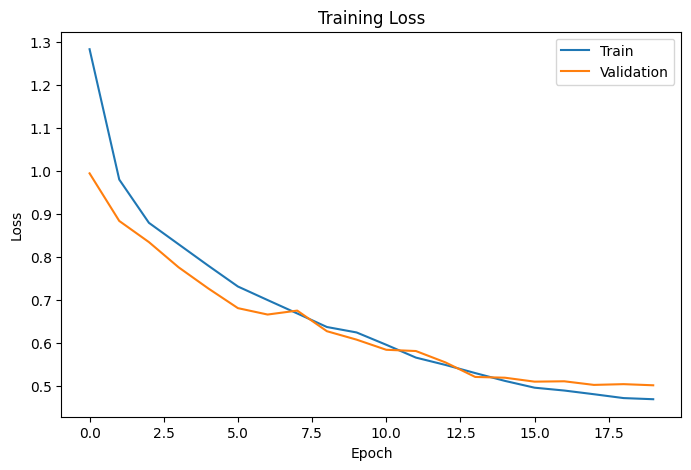

In [46]:
#plot training curves
plt.figure(figsize=(8,5))
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.show()

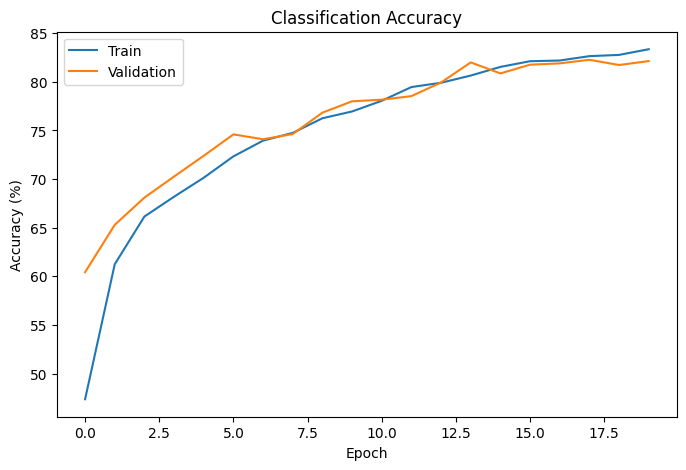

In [47]:
#plot accuracy
plt.figure(figsize=(8,5))
plt.plot(history["train_acc"], label="Train")
plt.plot(history["val_acc"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Classification Accuracy")
plt.legend()
plt.show()

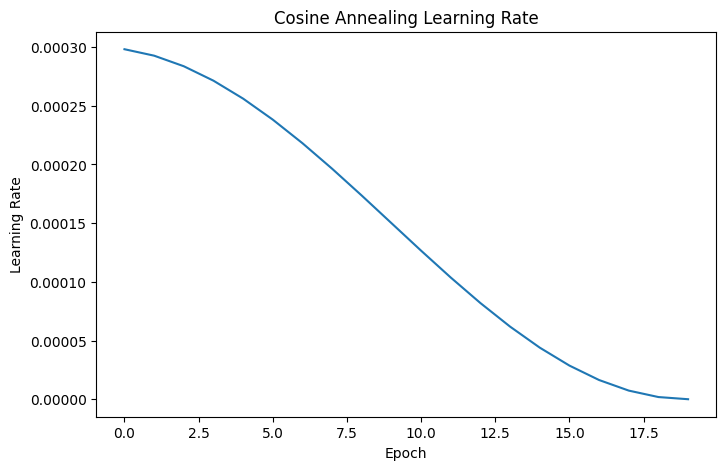

In [48]:
#learning rate curve (new shi visualised)
plt.figure(figsize=(8,5))
plt.plot(history["lr"])
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Cosine Annealing Learning Rate")
plt.show()

In [49]:
#final evaluation
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)
print(f"\nFinal Test Accuracy: {100*correct/total:.2f}%")

  0%|          | 0/94 [00:00<?, ?it/s]


Final Test Accuracy: 82.27%
